y_K: 0.343, y_D: 0.343


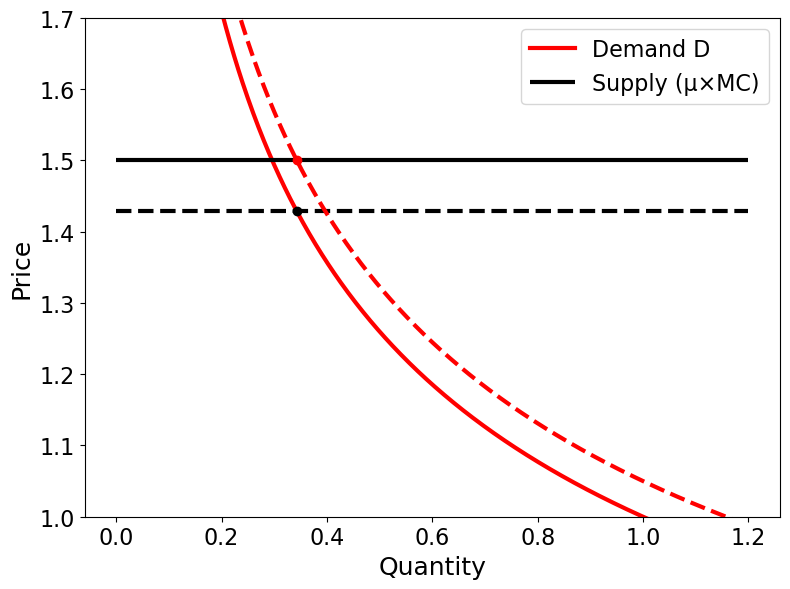

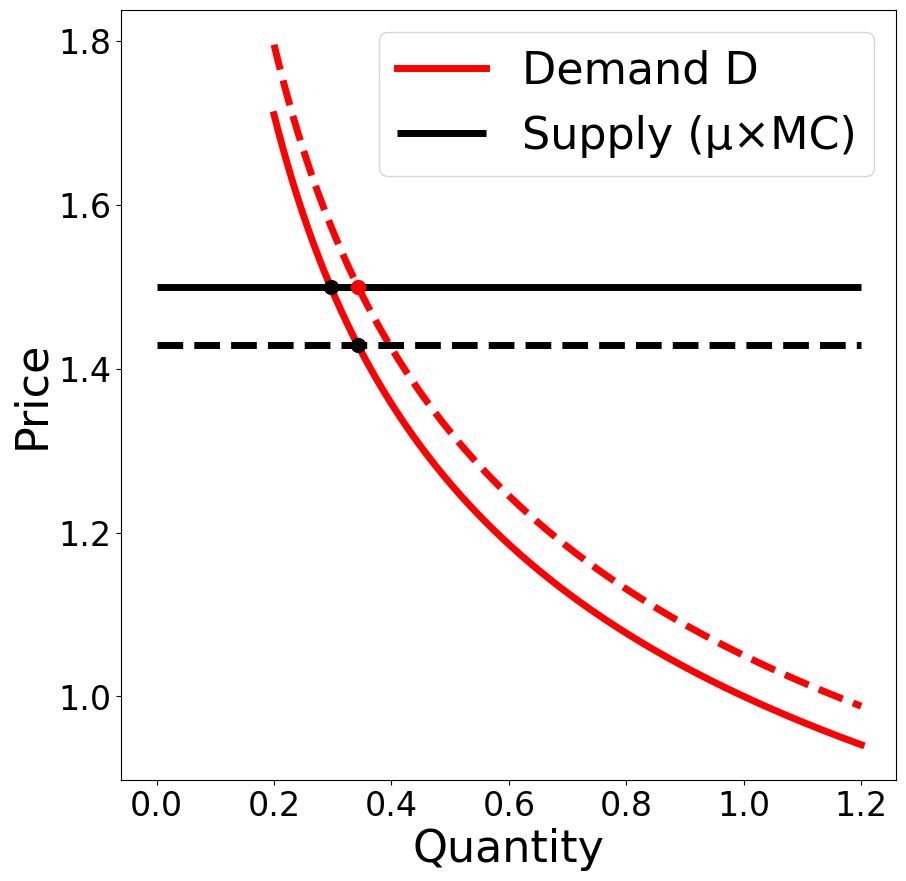

In [9]:
import numpy as np
from matplotlib import pyplot as plt

# directory for saving figures
MAIN_DIR = "/Users/jacobgosselin/Library/CloudStorage/GoogleDrive-jacob.gosselin@u.northwestern.edu/My Drive/research_ideas/negative_earnings"


# --- primitives ---
def p_of_y(y, d, sigma):
    return d * np.power(y, -1.0/sigma)

def MC(z):
    return 1.0 / z

def p_star(z, sigma):
    return (sigma / (sigma - 1.0)) * MC(z)

def y_star(d, z, sigma):
    return ((1.0 - 1.0/sigma) * d * z) ** sigma

def profit(d, z, sigma):
    return (p_star(z, sigma) - MC(z)) * y_star(d, z, sigma)

# --- params ---
d = 1.0
z = 1.0
sigma = 3.0
eps = 0.05  # small perturbation

# baselines
y0 = y_star(d, z, sigma)
p0 = p_star(z, sigma)
mc0 = MC(z)

# D bump (shift demand up)
d_D = d * (1.0 + eps)
y_D = y_star(d_D, z, sigma)
p_D = p_star(z, sigma)       
mc_D = MC(z)                 

# K bump (lower MC)
z_K = z * (1.0 + eps)
y_K = y_star(d, z_K, sigma)
p_K = p_star(z_K, sigma)
mc_K = MC(z_K)

# --- plotting grid ---
# y_grid = np.linspace(0.25, max(2.0, y_K*1.05, y_D*1.05), 500)
y_grid = np.linspace(0.2, 1.2, 500)
p_grid = p_of_y(y_grid, d, sigma)
p_grid_D = p_of_y(y_grid, d_D, sigma)

# print y_K and y_D for reference
print(f"y_K: {y_K:.3f}, y_D: {y_D:.3f}")

plt.figure(figsize=(8, 6))

# Initial lines
plt.plot(y_grid, p_grid, color="red", linewidth=3, label="Demand D")
# plt.hlines(mc0, 0, y0, color="black", linestyle="--", linewidth=3, label="MC")
plt.hlines(p0, 0, y_grid[-1], color="black", linewidth=3, label="Supply (μ×MC)")
# plt.scatter([y0], [p0], color="black", zorder=5)
# plt.fill_between([0, y0], [mc0, mc0], [p0, p0], alpha=0.25, color="grey")
plt.xlabel("Quantity", fontsize=18)
plt.ylabel("Price", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(loc="upper right", frameon=True, fontsize=16)
plt.ylim(1.0, 1.7)
# save fig 1
plt.savefig(MAIN_DIR + "/figures/misc/stylizedSEP_1.pdf", bbox_inches="tight")

# Supply bump
# plt.hlines(mc_K, 0, y_K, color="blue", linestyle="--", linewidth=3)
plt.hlines(p_K, 0, y_grid[-1], color="black", linestyle="--", linewidth=3)
plt.scatter([y_K], [p_K], color="black", zorder=5)
# Gain = MC savings on original units + margin on new units
# plt.fill_between([0, y0],   [mc_K, mc_K], [mc0, mc0], alpha=0.25, color="blue", 
# plt.fill_between([0, y_K], [mc_K, mc_K], [p_K, p_K], alpha=0.25, color="blue", label=f"π from $\Delta K$")
plt.legend(loc="upper right", frameon=True, fontsize=16)

# save fig2
# tight layout to avoid cutting off legend
plt.tight_layout()
plt.savefig(MAIN_DIR + "/figures/misc/stylizedSEP_2.pdf", bbox_inches="tight")

# Demand bump
plt.plot(y_grid, p_grid_D, color="red", linewidth=3, linestyle="--")
plt.scatter([y_D], [p_D], color="red", zorder=5)
# Gain = price gain on original units + margin on new units
# plt.fill_between([0, y0],   [p0,   p0],   [p_D, p_D], alpha=0.25, color="crimson", label="Δπ from D")
# plt.fill_between([0, y_D], [mc_D, mc_D], [p_D, p_D], alpha=0.25, color="crimson", label=f"π from $\Delta D$")
plt.legend(loc="upper right", frameon=True, fontsize=16)

# save fig3
plt.savefig(MAIN_DIR + "/figures/misc/stylizedSEP_3.pdf", bbox_inches="tight")

# resize figure as 10x10 for slides
plt.figure(figsize=(10, 10))
plt.plot(y_grid, p_grid, color="red", linewidth=5, label="Demand D")
plt.hlines(p0, 0, y_grid[-1], color="black", linewidth=5, label="Supply (μ×MC)")
plt.plot(y_grid, p_grid_D, color="red", linewidth=5, linestyle="--")
plt.hlines(p_K, 0, y_grid[-1], color="black", linestyle="--", linewidth=5)
plt.scatter([y0], [p0], color="black", zorder = 5, s=100)
plt.scatter([y_K], [p_K], color="black", zorder=5, s=100)
plt.scatter([y_D], [p_D], color="red", zorder=5, s=100)
plt.xlabel("Quantity", fontsize=32)
plt.ylabel("Price", fontsize=32)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(loc="upper right", frameon=True, fontsize=32)
plt.savefig(MAIN_DIR + "/figures/misc/stylizedSEP_slides.pdf", bbox_inches="tight")
